#  Random Forest

## The Idea
Instead of one decision tree, create **many trees** and let them vote!

## Why?
- One tree = can overfit (memorizes data)
- Many trees = more stable, more accurate

## How?
1. Create multiple random subsets of data (bootstrap)
2. Train a tree on each subset
3. For prediction: majority vote (classification) or average (regression)

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score

# Load iris dataset
iris = load_iris()
X, y = iris.data, iris.target

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 120
Testing samples: 30


In [5]:
# Single Decision Tree
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
tree_pred = tree.predict(X_test)
tree_acc = accuracy_score(y_test, tree_pred)

# Random Forest (100 trees)
forest = RandomForestClassifier(n_estimators=100, random_state=42)
forest.fit(X_train, y_train)
forest_pred = forest.predict(X_test)
forest_acc = accuracy_score(y_test, forest_pred)

print(f"Decision Tree Accuracy: {tree_acc:.4f}")
print(f"Random Forest Accuracy: {forest_acc:.4f}")
print(f"Improvement: {forest_acc - tree_acc:.4f}")

Decision Tree Accuracy: 1.0000
Random Forest Accuracy: 1.0000
Improvement: 0.0000


sepal length (cm): 0.1081
sepal width (cm): 0.0304
petal length (cm): 0.4400
petal width (cm): 0.4215


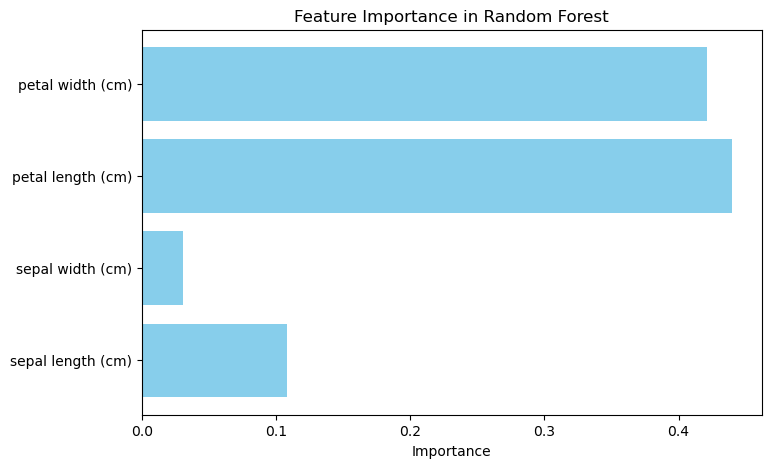

In [6]:
# Feature Importance
importances = forest.feature_importances_
feature_names = iris.feature_names

for name, importance in zip(feature_names, importances):
    print(f"{name}: {importance:.4f}")

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.barh(feature_names, importances, color='skyblue')
plt.xlabel("Importance")
plt.title("Feature Importance in Random Forest")
plt.show()